In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sro_sto_plume import microscopy as mic


# Batch Roughness Comparison Across Area Exports

This notebook loads the full-area height maps exported as TXT files, flattens them (optional), and reports roughness in two ways:

1. Treat every pixel across all images in a folder as a single surface and compute Ra/Rq/Rz.
2. Compute the mean height of each image, then evaluate the variation of those means (image-to-image roughness).

Update the configuration below to point at the folders you would like to compare.

In [2]:
# --- Configuration ---
DATA_FOLDERS = [
    {"name": "sanded", "path": Path("../data/TargetMicroscopy/Scan2/sanded/"),  "loader": "datx", "pattern": "*.datx"},
    {"name": "G1", "path": Path("../data/TargetMicroscopy/Scan2/G1/"),  "loader": "datx", "pattern": "*.datx"},
    {"name": "G2", "path": Path("../data/TargetMicroscopy/Scan2/G2/"),   "loader": "datx", "pattern": "*.datx"},
    {"name": "G3", "path": Path("../data/TargetMicroscopy/Scan2/G3/"),   "loader": "datx", "pattern": "*.datx"},
    {"name": "G4", "path": Path("../data/TargetMicroscopy/Scan2/G4/"),   "loader": "datx", "pattern": "*.datx"},
    {"name": "G5", "path": Path("../data/TargetMicroscopy/Scan2/G5/"),   "loader": "datx", "pattern": "*.datx"},
]
PATTERN = "*.datx"           # default glob pattern
DETREND = False               # remove best-fit plane before computing roughness
ZERO_CENTER = False           # subtract per-image mean (after detrend)
HEIGHT_SCALE = 1e6           # meters -> micrometers
HEIGHT_UNIT = "µm"

In [3]:
def analyze_area_folder(folder_path: Path,
                          name: str | None = None,
                          *,
                          pattern: str = "*.txt",
                          loader: str = "txt",
                          dataset_keyword: str = "Surface",
                          detrend: bool = False,
                          zero_center: bool = False,
                          scale: float = 1.0,
                          unit: str = "µm"):
    """Compute batch roughness metrics for all height maps in a folder."""

    folder_path = Path(folder_path)
    files = sorted(folder_path.glob(pattern))
    if not files:
        raise ValueError(f"No files matching {pattern!r} in {folder_path}")

    loader_lower = loader.lower()
    if loader_lower == "txt":
        batch = mic.batch_roughness_from_txt(files, detrend=detrend, zero_center=zero_center)
    elif loader_lower == "datx":
        batch = mic.batch_roughness_from_datx(files,
                                             dataset_keyword=dataset_keyword,
                                             detrend=detrend,
                                             zero_center=zero_center)
    else:
        raise ValueError(f"Unsupported loader '{loader}'. Use 'txt' or 'datx'.")

    def scale_record(record: dict[str, float]) -> dict[str, float]:
        rec = record.copy()
        for key in ("mean", "Ra", "Rq", "Rz"):
            rec[key] = rec[key] * scale
        return rec

    folder_label = name or folder_path.name

    global_stats = scale_record(batch["global_pixels"])
    global_stats.update({
        "folder": folder_label,
        "n_images": len(batch["per_image"]),
        "count": batch["global_pixels"]["count"],
        "detrended": detrend,
        "zero_center": zero_center,
        "unit": unit,
    })

    mean_stats = scale_record(batch["image_mean_variation"])
    mean_stats.update({
        "folder": folder_label,
        "count": batch["image_mean_variation"]["count"],
        "detrended": detrend,
        "zero_center": zero_center,
        "unit": unit,
    })

    per_image_rows = []
    for file, record in zip(files, batch["per_image"]):
        scaled = scale_record(record)
        scaled.update({
            "folder": folder_label,
            "path": str(file),
            "count": record["count"],
            "detrended": detrend,
            "zero_center": zero_center,
            "unit": unit,
        })
        per_image_rows.append(scaled)

    per_image_df = pd.DataFrame(per_image_rows)

    return global_stats, mean_stats, per_image_df



## Compute batch roughness statistics

For each folder, the code below:

- loads all TXT files matching `PATTERN`,
- optionally detrends each map,
- records per-image roughness metrics,
- aggregates across all pixels,
- computes image-to-image variation (based on the mean height per image).

In [4]:
folder_summaries = []
mean_summaries = []
per_image_frames = []

for entry in DATA_FOLDERS:
    folder_name = entry["name"]
    folder_path = entry["path"]
    loader = entry.get("loader", "txt")
    dataset_keyword = entry.get("dataset_keyword", "Surface")
    pattern = entry.get("pattern", PATTERN)

    try:
        global_stats, mean_stats, per_image_df = analyze_area_folder(
            folder_path,
            name=folder_name,
            pattern=pattern,
            loader=loader,
            dataset_keyword=dataset_keyword,
            detrend=DETREND,
            zero_center=ZERO_CENTER,
            scale=HEIGHT_SCALE,
            unit=HEIGHT_UNIT,
        )
    except ValueError as exc:
        print(f"[WARN] {exc}")
        continue

    folder_summaries.append(global_stats)
    mean_summaries.append(mean_stats)
    per_image_frames.append(per_image_df)

if not folder_summaries:
    raise ValueError("No folders produced data. Check DATA_FOLDERS and PATTERN.")

folder_df = pd.DataFrame(folder_summaries).set_index("folder")
mean_df = pd.DataFrame(mean_summaries).set_index("folder")
per_image_df = pd.concat(per_image_frames, ignore_index=True)

print("Global pixel-wise roughness (all pixels pooled)")
display(folder_df[["mean", "Ra", "Rq", "Rz", "count", "n_images", "detrended", "zero_center", "unit"]])

print("Image-to-image variation (based on image means)")
display(mean_df[["mean", "Ra", "Rq", "Rz", "count", "detrended", "zero_center", "unit"]])

print("Per-image roughness metrics")
display(per_image_df[["folder", "path", "mean", "Ra", "Rq", "Rz", "count", "detrended", "zero_center", "unit"]])



Global pixel-wise roughness (all pixels pooled)


,mean,Ra,Rq,Rz,count,n_images,detrended,zero_center,unit
folder,,,,,,,,,
sanded,51.753510,6.827593,8.386774,68.403026,5728463,6,False,False,µm
G1,51.735636,5.923445,7.234559,99.321171,6406263,8,False,False,µm
G2,50.513759,6.342945,7.834793,99.762961,5887602,8,False,False,µm
G3,51.713137,6.003733,7.372188,98.553100,4244495,7,False,False,µm
G4,50.874086,5.697042,7.035795,98.665083,4048405,6,False,False,µm
G5,52.711941,6.579916,8.130951,98.090550,2775769,4,False,False,µm


Image-to-image variation (based on image means)


,mean,Ra,Rq,Rz,count,detrended,zero_center,unit
folder,,,,,,,,
sanded,51.762686,4.126608,4.751161,12.938566,6,False,False,µm
G1,51.684189,1.378553,1.852869,6.062215,8,False,False,µm
G2,50.324364,2.799353,3.737585,13.393397,8,False,False,µm
G3,51.572932,2.653199,3.043396,8.955836,7,False,False,µm
G4,50.850442,2.224575,2.584867,7.680293,6,False,False,µm
G5,52.708536,1.594204,1.713539,4.361851,4,False,False,µm


Per-image roughness metrics


,folder,path,mean,Ra,Rq,Rz,count,detrended,zero_center,unit
0,sanded,../data/TargetMicroscopy/Scan2/sanded/s1.datx,51.345291,4.273773,5.386655,43.598751,971868,False,False,µm
1,sanded,../data/TargetMicroscopy/Scan2/sanded/s2.datx,44.742883,4.704060,5.825871,57.101105,943395,False,False,µm
2,sanded,../data/TargetMicroscopy/Scan2/sanded/s3.datx,46.820061,7.505029,8.952341,60.706878,954014,False,False,µm
3,sanded,../data/TargetMicroscopy/Scan2/sanded/s4.datx,53.311639,6.798546,8.025161,49.314161,978549,False,False,µm
4,sanded,../data/TargetMicroscopy/Scan2/sanded/s5.datx,57.681449,4.541956,5.618221,54.020266,931053,False,False,µm
5,sanded,../data/TargetMicroscopy/Scan2/sanded/s6.datx,56.674795,5.815521,6.960102,51.616192,949584,False,False,µm
6,G1,../data/TargetMicroscopy/Scan2/G1/s1.datx,51.662634,5.686941,6.849692,92.778080,836629,False,False,µm
7,G1,../data/TargetMicroscopy/Scan2/G1/s2.datx,52.877007,5.702051,7.080155,69.992184,858667,False,False,µm
8,G1,../data/TargetMicroscopy/Scan2/G1/s3.datx,51.789664,5.737620,6.966446,81.894998,789002,False,False,µm
9,G1,../data/TargetMicroscopy/Scan2/G1/s4.datx,52.208060,6.340901,7.769922,84.165883,801324,False,False,µm


## Visual comparisons

Bar plots and strip plots make it easier to compare roughness across folders.

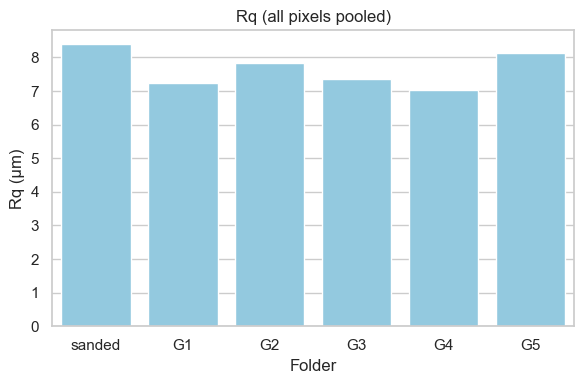

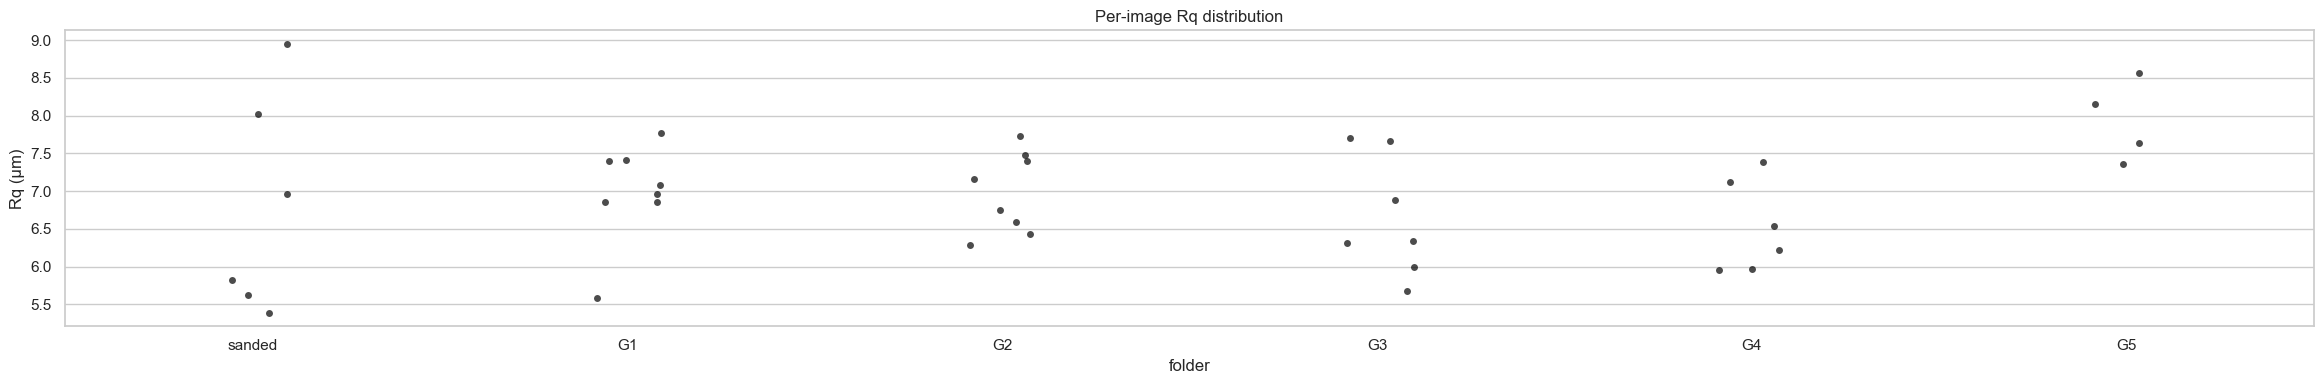

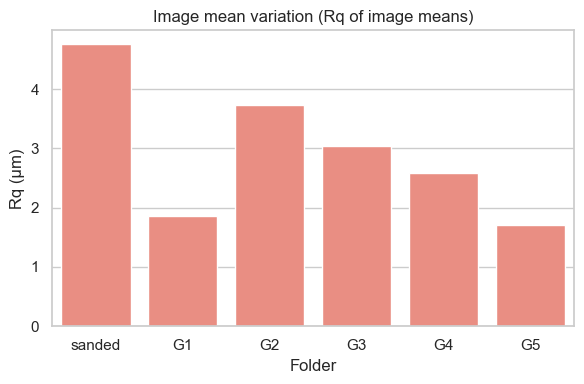

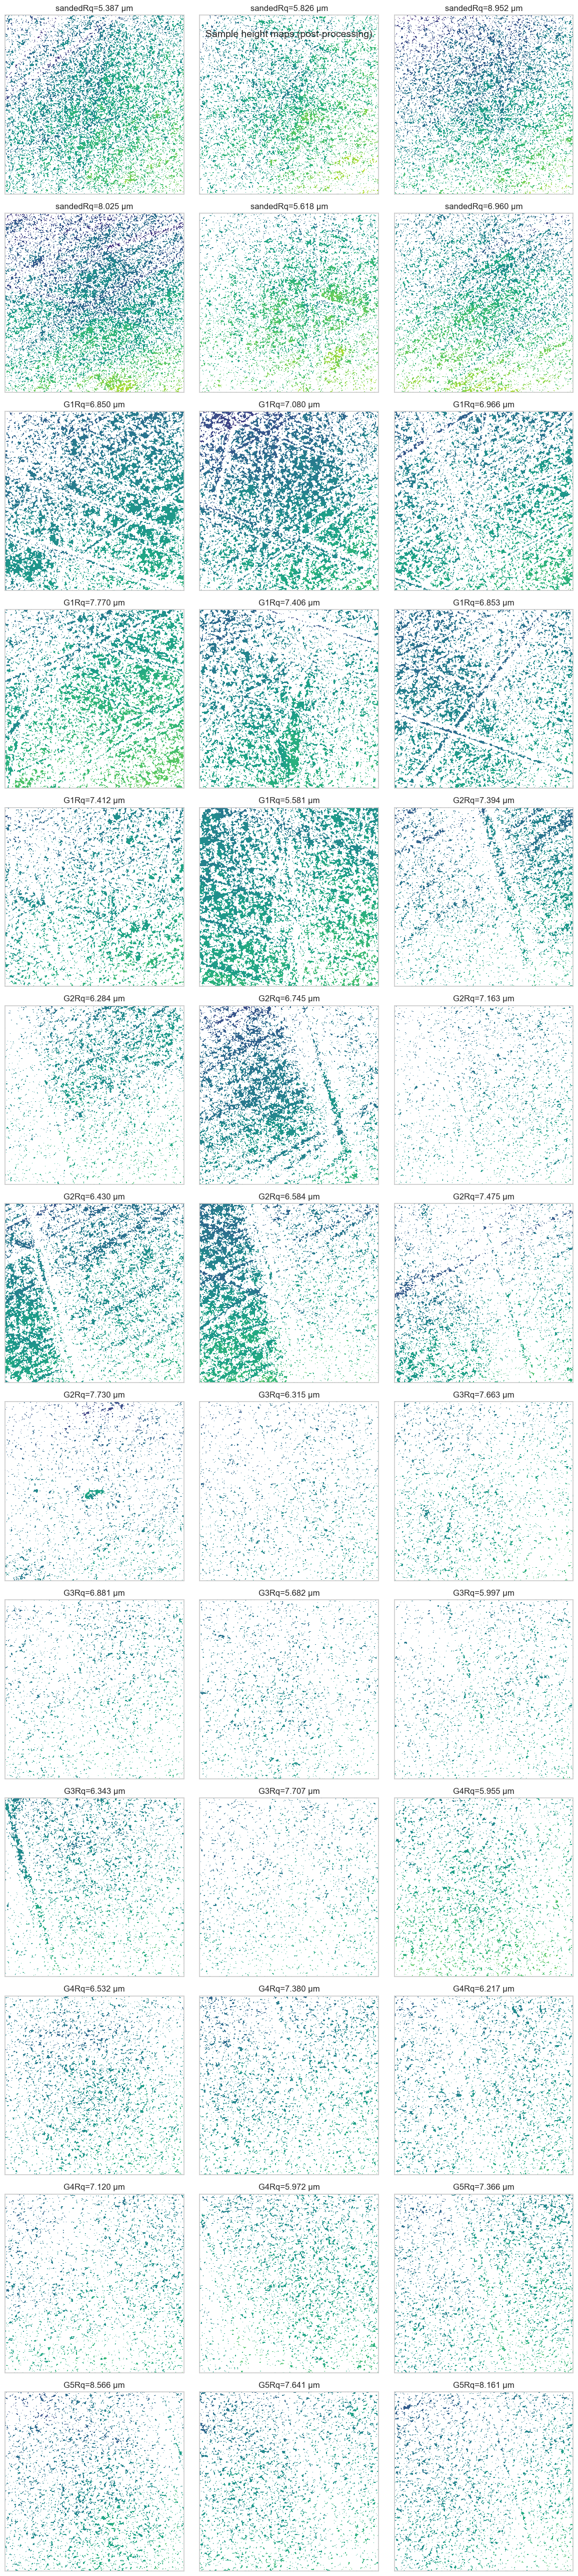

In [5]:
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(max(6, len(folder_df) * 1.0), 4))
sns.barplot(x=folder_df.index, y="Rq", data=folder_df.reset_index(), ax=ax, color="skyblue")
ax.set_ylabel(f"Rq ({HEIGHT_UNIT})")
ax.set_xlabel("Folder")
ax.set_title("Rq (all pixels pooled)")
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(max(6, len(per_image_df) * 0.6), 4))
sns.stripplot(data=per_image_df, x="folder", y="Rq", ax=ax, color="black", alpha=0.7)
ax.set_ylabel(f"Rq ({HEIGHT_UNIT})")
ax.set_title("Per-image Rq distribution")
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(max(6, len(mean_df) * 1.0), 4))
sns.barplot(x=mean_df.index, y="Rq", data=mean_df.reset_index(), ax=ax, color="salmon")
ax.set_ylabel(f"Rq ({HEIGHT_UNIT})")
ax.set_xlabel("Folder")
ax.set_title("Image mean variation (Rq of image means)")
fig.tight_layout()
plt.show()

# Thumbnail visualization
n_images = len(per_image_df)
if n_images:
    ncols = min(3, n_images)
    nrows = int(np.ceil(n_images / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    axes = np.atleast_1d(axes).flatten()

    for ax in axes[n_images:]:
        ax.axis('off')

    for ax, row in zip(axes, per_image_df.itertuples()):
        path = Path(row.path)
        loader = next((entry.get('loader', 'txt').lower() for entry in DATA_FOLDERS
                       if entry['name'] == row.folder), 'txt')

        if loader == 'datx':
            data = mic.load_datx_height_map(path)
        else:
            data = mic.load_height_txt(path)

        if DETREND:
            data = mic._detrend_plane(data)
        if ZERO_CENTER:
            mean_val = np.nanmean(data)
            if np.isfinite(mean_val):
                data = data - mean_val

        ax.imshow(data, cmap='viridis')
        ax.set_title(f"{row.folder}Rq={row.Rq:.3f} {HEIGHT_UNIT}")
        ax.set_xticks([])
        ax.set_yticks([])

    fig.suptitle('Sample height maps (post-processing)', fontsize=14)
    fig.tight_layout()

plt.show()

